# Future Vision Transport — segmentation sémantique

Future Vision Transport développe des systèmes embarqués de vision pour véhicules autonomes. Ce projet porte sur la segmentation sémantique des images. L’objectif est de comparer quatre architectures afin d’identifier un modèle performant, reproductible et suffisamment efficace pour s’intégrer à la chaîne de traitement embarquée.

Le notebook compare **U-Net baseline**, **U-Net + MobileNetV2**, **DeepLabV3** et **SegFormer** sur un même jeu de validation. Chaque entraînement est indépendant et enregistre ses paramètres, métriques et artefacts dans MLflow.

## Partie 1 — Analyse et préparation des données

### 1. Imports et initialisation du projet

In [1]:
import sys
import warnings
from pathlib import Path

import albumentations as A
import cv2
import matplotlib.pyplot as plt
import mlflow
import numpy as np
import pandas as pd
import torch
from IPython.display import display

RACINE_PROJET = Path.cwd().resolve()
if RACINE_PROJET.name.lower() in {"notebook", "notebooks"}:
    RACINE_PROJET = RACINE_PROJET.parent
if str(RACINE_PROJET) not in sys.path:
    sys.path.insert(0, str(RACINE_PROJET))

from fonctions.segmentation import (
    COULEURS_CATEGORIES, NOMS_CATEGORIES, choisir_peripherique,
    construire_modele, creer_chargeurs, creer_tableau_donnees,
    analyser_distribution_categories, entrainer_modele_mlflow, fixer_aleatoire,
    recuperer_classement_mlflow, separer_donnees, pretraiter_donnees,
    convertir_masque_huit_categories, verifier_couples_images_masques,
)

warnings.filterwarnings("ignore")
GRAINE = 42
fixer_aleatoire(GRAINE)
PERIPHERIQUE = choisir_peripherique()
print("PyTorch :", torch.__version__)
print("Périphérique :", PERIPHERIQUE)
if PERIPHERIQUE.type == "xpu":
    print("GPU Intel :", torch.xpu.get_device_name(0))

/home/david/future_vision_transport_xpu/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


PyTorch : 2.7.1+xpu
Périphérique : xpu
GPU Intel : Intel(R) Graphics [0x7d55]


### 2. Configuration générale

In [2]:
LARGEUR_IMAGE = 256
HAUTEUR_IMAGE = 128
NOMBRE_CLASSES = 8
ID_VIDE = 0
PROPORTION_VALIDATION = 0.20
NOMBRE_TRAVAILLEURS = 0

CONFIGURATIONS_MODELES = {
    "unet_baseline": {"taille_lot": 4, "nombre_epoques": 30, "taux_apprentissage": 1e-3, "patience": 4, "poids_preentraines": False},
    "unet_mobilenetv2": {"taille_lot": 4, "nombre_epoques": 30, "taux_apprentissage": 1e-4, "patience": 5, "poids_preentraines": True},
    "deeplabv3": {"taille_lot": 2, "nombre_epoques": 35, "taux_apprentissage": 1e-4, "patience": 5, "poids_preentraines": True},
    "segformer": {"taille_lot": 2, "nombre_epoques": 35, "taux_apprentissage": 6e-5, "patience": 5, "poids_preentraines": True},
}
display(pd.DataFrame(CONFIGURATIONS_MODELES).T)

,taille_lot,nombre_epoques,taux_apprentissage,patience,poids_preentraines
unet_baseline,4,30,0.001,4,False
unet_mobilenetv2,4,30,0.0001,5,True
deeplabv3,2,35,0.0001,5,True
segformer,2,35,0.00006,5,True


### 3. Chemins, MLflow et données Cityscapes

In [3]:
DOSSIER_IMAGES = (
    RACINE_PROJET
    / "data"
    / "P8_Cityscapes_leftImg8bit_trainvaltest"
    / "leftImg8bit"
    / "train"
)

DOSSIER_MASQUES = (
    RACINE_PROJET
    / "data"
    / "P8_Cityscapes_gtFine_trainvaltest"
    / "gtFine"
    / "train"
)

DOSSIER_ARTIFACTS = RACINE_PROJET / ".artifacts_segmentation"
DOSSIER_ARTIFACTS.mkdir(parents=True, exist_ok=True)

DOSSIER_PRETRAITE = RACINE_PROJET / "data" / "pretraitees"
CHEMIN_INDEX_PRETRAITE = (
    DOSSIER_PRETRAITE / "index_pretraite.csv"
)

URI_MLFLOW = (
    f"sqlite:///"
    f"{(RACINE_PROJET / 'mlflow.db').as_posix()}"
)

NOM_EXPERIENCE_MLFLOW = (
    "future_vision_transport_segmentation_xpu"
)

mlflow.set_tracking_uri(URI_MLFLOW)
mlflow.set_experiment(NOM_EXPERIENCE_MLFLOW)

if (
    not DOSSIER_IMAGES.exists()
    or not DOSSIER_MASQUES.exists()
):
    raise FileNotFoundError(
        "Déposez les dossiers Cityscapes dans data/ "
        "selon les chemins définis ci-dessus."
    )

# --------------------------------------------------
# 1. Création du tableau à partir des données brutes
# --------------------------------------------------

tableau_donnees = creer_tableau_donnees(
    DOSSIER_IMAGES,
    DOSSIER_MASQUES,
)

# --------------------------------------------------
# 2. Vérification des couples image / masque
# --------------------------------------------------

rapport_couples = verifier_couples_images_masques(
    tableau_donnees
)

indices_lisibles = rapport_couples.loc[
    rapport_couples["image_lisible"]
    & rapport_couples["masque_lisible"],
    "indice",
]

tableau_donnees = (
    tableau_donnees
    .iloc[indices_lisibles]
    .reset_index(drop=True)
)

# --------------------------------------------------
# 3. Création ou chargement du cache prétraité
# --------------------------------------------------

if CHEMIN_INDEX_PRETRAITE.exists():

    tableau_donnees_pretraitees = pd.read_csv(
        CHEMIN_INDEX_PRETRAITE
    )

    print("Cache prétraité chargé.")

else:

    tableau_donnees_pretraitees = pretraiter_donnees(
        tableau=tableau_donnees,
        dossier_sortie=DOSSIER_PRETRAITE,
        largeur=LARGEUR_IMAGE,
        hauteur=HAUTEUR_IMAGE,
    )

    tableau_donnees_pretraitees.to_csv(
        CHEMIN_INDEX_PRETRAITE,
        index=False,
    )

    print("Cache prétraité créé.")

# --------------------------------------------------
# 4. Séparation train / validation
# --------------------------------------------------

tableau_entrainement, tableau_validation = (
    separer_donnees(
        tableau_donnees_pretraitees,
        PROPORTION_VALIDATION,
        GRAINE,
    )
)

# --------------------------------------------------
# 5. Vérifications
# --------------------------------------------------

print(
    "Total lisible :",
    len(tableau_donnees)
)

print(
    "Total prétraité :",
    len(tableau_donnees_pretraitees)
)

print(
    "Entraînement :",
    len(tableau_entrainement)
)

print(
    "Validation :",
    len(tableau_validation)
)

print("\nPremier chemin image :")
print(
    tableau_entrainement.iloc[0]["chemin_image"]
)

print("\nPremier chemin masque :")
print(
    tableau_entrainement.iloc[0]["chemin_masque"]
)

display(
    tableau_donnees_pretraitees.head()
)

Cache prétraité chargé.
Total lisible : 2974
Total prétraité : 2974
Entraînement : 2379
Validation : 595

Premier chemin image :
/home/david/future_vision_transport_xpu/data/pretraitees/images/002395_image.png

Premier chemin masque :
/home/david/future_vision_transport_xpu/data/pretraitees/masques_8_categories/002395_masque.png


,ville,chemin_image,chemin_masque
0,aachen,/home/david/future_vision_transport_xpu/data/p...,/home/david/future_vision_transport_xpu/data/p...
1,aachen,/home/david/future_vision_transport_xpu/data/p...,/home/david/future_vision_transport_xpu/data/p...
2,aachen,/home/david/future_vision_transport_xpu/data/p...,/home/david/future_vision_transport_xpu/data/p...
3,aachen,/home/david/future_vision_transport_xpu/data/p...,/home/david/future_vision_transport_xpu/data/p...
4,aachen,/home/david/future_vision_transport_xpu/data/p...,/home/david/future_vision_transport_xpu/data/p...


In [4]:
image_test = cv2.imread(
    tableau_entrainement.iloc[0]["chemin_image"]
)

print(image_test.shape)

(128, 256, 3)


### 4. Vérification des couples image–masque

In [4]:
nombre_couples = len(rapport_couples)
nombre_illisibles = int((~rapport_couples["image_lisible"] | ~rapport_couples["masque_lisible"]).sum())
nombre_dimensions_identiques = int(rapport_couples["memes_dimensions"].sum())
nombre_dimensions_differentes = int(
    (
        rapport_couples["image_lisible"]
        & rapport_couples["masque_lisible"]
        & ~rapport_couples["memes_dimensions"]
    ).sum()
)

resume_controle = pd.DataFrame([{
    "couples_recenses": nombre_couples,
    "couples_lisibles": nombre_couples - nombre_illisibles,
    "fichiers_illisibles": nombre_illisibles,
    "dimensions_identiques": nombre_dimensions_identiques,
    "dimensions_differentes": nombre_dimensions_differentes,
}])
display(resume_controle)

anomalies_couples = rapport_couples.loc[
    (~rapport_couples["image_lisible"])
    | (~rapport_couples["masque_lisible"])
    | (~rapport_couples["memes_dimensions"])
].copy()

if anomalies_couples.empty:
    print("Tous les couples image–masque sont lisibles et possèdent les mêmes dimensions.")
else:
    print(
        "Les anomalies sont affichées ci-dessous. "
        "Les fichiers illisibles sont exclus et les masques de dimensions différentes "
        "seront réalignés par interpolation nearest-neighbor dans le Dataset."
    )
    display(anomalies_couples.head(20))

,couples_recenses,couples_lisibles,fichiers_illisibles,dimensions_identiques,dimensions_differentes
0,2975,2974,1,2974,0


Les anomalies sont affichées ci-dessous. Les fichiers illisibles sont exclus et les masques de dimensions différentes seront réalignés par interpolation nearest-neighbor dans le Dataset.


,indice,ville,chemin_image,chemin_masque,image_lisible,masque_lisible,hauteur_image,largeur_image,hauteur_masque,largeur_masque,memes_dimensions
2105,2105,strasbourg,/home/david/future_vision_transport_xpu/data/P...,/home/david/future_vision_transport_xpu/data/P...,True,False,1024,2048,NaN,NaN,False


### 5. Regroupement en 8 catégories et analyse du déséquilibre

,identifiant_categorie,categorie,nombre_pixels,proportion_pixels_pourcent
0,0,vide,639080892,10.247 %
1,1,plat,2421843750,38.831 %
2,2,construction,1366970214,21.917 %
3,3,objet,110161566,1.766 %
4,4,nature,943149279,15.122 %
5,5,ciel,221925862,3.558 %
6,6,humain,74789133,1.199 %
7,7,vehicule,459009352,7.360 %


Rapport entre la catégorie la plus représentée et la moins représentée : 32.38


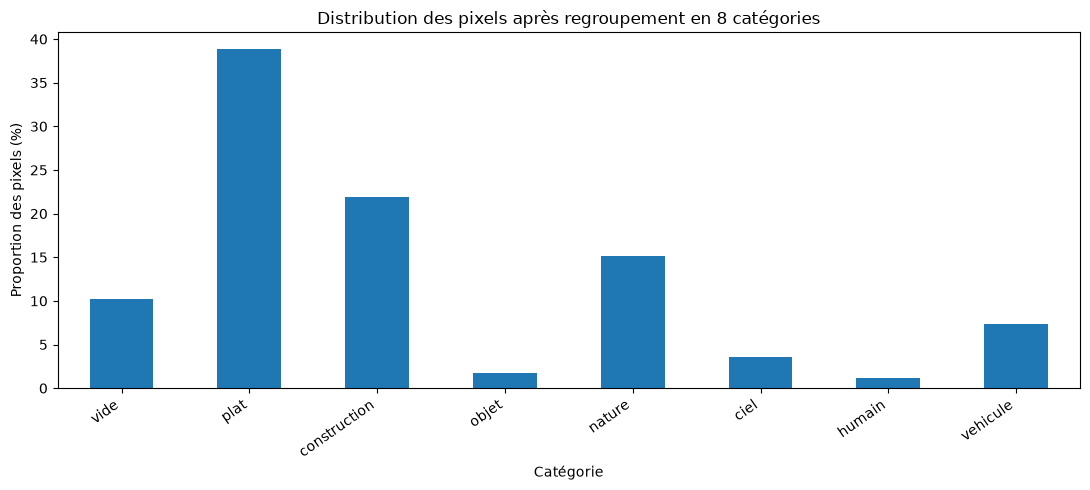

Un déséquilibre important est observé. Les métriques mIoU et Dice par classe seront privilégiées par rapport à la seule précision pixel.
Catégories d'apprentissage : {0: 'vide', 1: 'plat', 2: 'construction', 3: 'objet', 4: 'nature', 5: 'ciel', 6: 'humain', 7: 'vehicule'}


In [5]:
distribution_categories = analyser_distribution_categories(
    tableau_donnees,
    NOMS_CATEGORIES,
)

rapport_desequilibre = distribution_categories.attrs.get(
    "rapport_desequilibre",
    0.0,
)

display(
    distribution_categories[
        [
            "identifiant_categorie",
            "categorie",
            "nombre_pixels",
            "proportion_pixels_pourcent",
        ]
    ].style.format({"proportion_pixels_pourcent": "{:.3f} %"})
)

print(f"Rapport entre la catégorie la plus représentée et la moins représentée : {rapport_desequilibre:.2f}")

ax = distribution_categories.plot.bar(
    x="categorie",
    y="proportion_pixels_pourcent",
    legend=False,
    figsize=(11, 5),
    title="Distribution des pixels après regroupement en 8 catégories",
)
ax.set_xlabel("Catégorie")
ax.set_ylabel("Proportion des pixels (%)")
plt.xticks(rotation=35, ha="right")
plt.tight_layout()
plt.show()

if rapport_desequilibre >= 10:
    print(
        "Un déséquilibre important est observé. Les métriques mIoU et Dice par classe "
        "seront privilégiées par rapport à la seule précision pixel."
    )
else:
    print("Le déséquilibre entre catégories reste modéré.")

print("Catégories d'apprentissage :", dict(enumerate(NOMS_CATEGORIES)))

### 6. Visualisation d’un couple image–masque

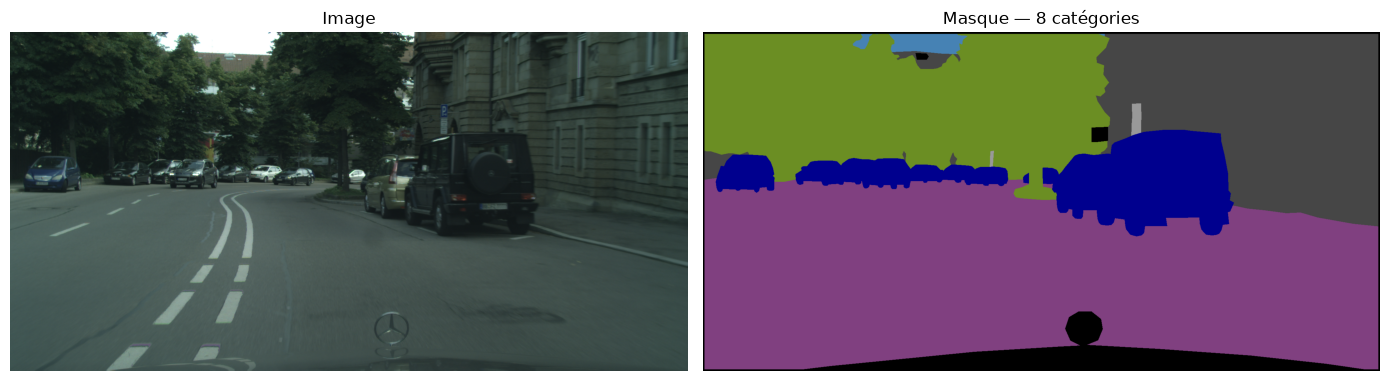

In [6]:
ligne = tableau_entrainement.iloc[0]
image = cv2.cvtColor(cv2.imread(ligne.chemin_image), cv2.COLOR_BGR2RGB)
masque_brut = cv2.imread(ligne.chemin_masque, cv2.IMREAD_UNCHANGED)
masque = convertir_masque_huit_categories(masque_brut)
masque_couleur = COULEURS_CATEGORIES[masque]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].imshow(image); axes[0].set_title("Image"); axes[0].axis("off")
axes[1].imshow(masque_couleur); axes[1].set_title("Masque — 8 catégories"); axes[1].axis("off")
plt.tight_layout()

### 7. Data augmentation — six exemples

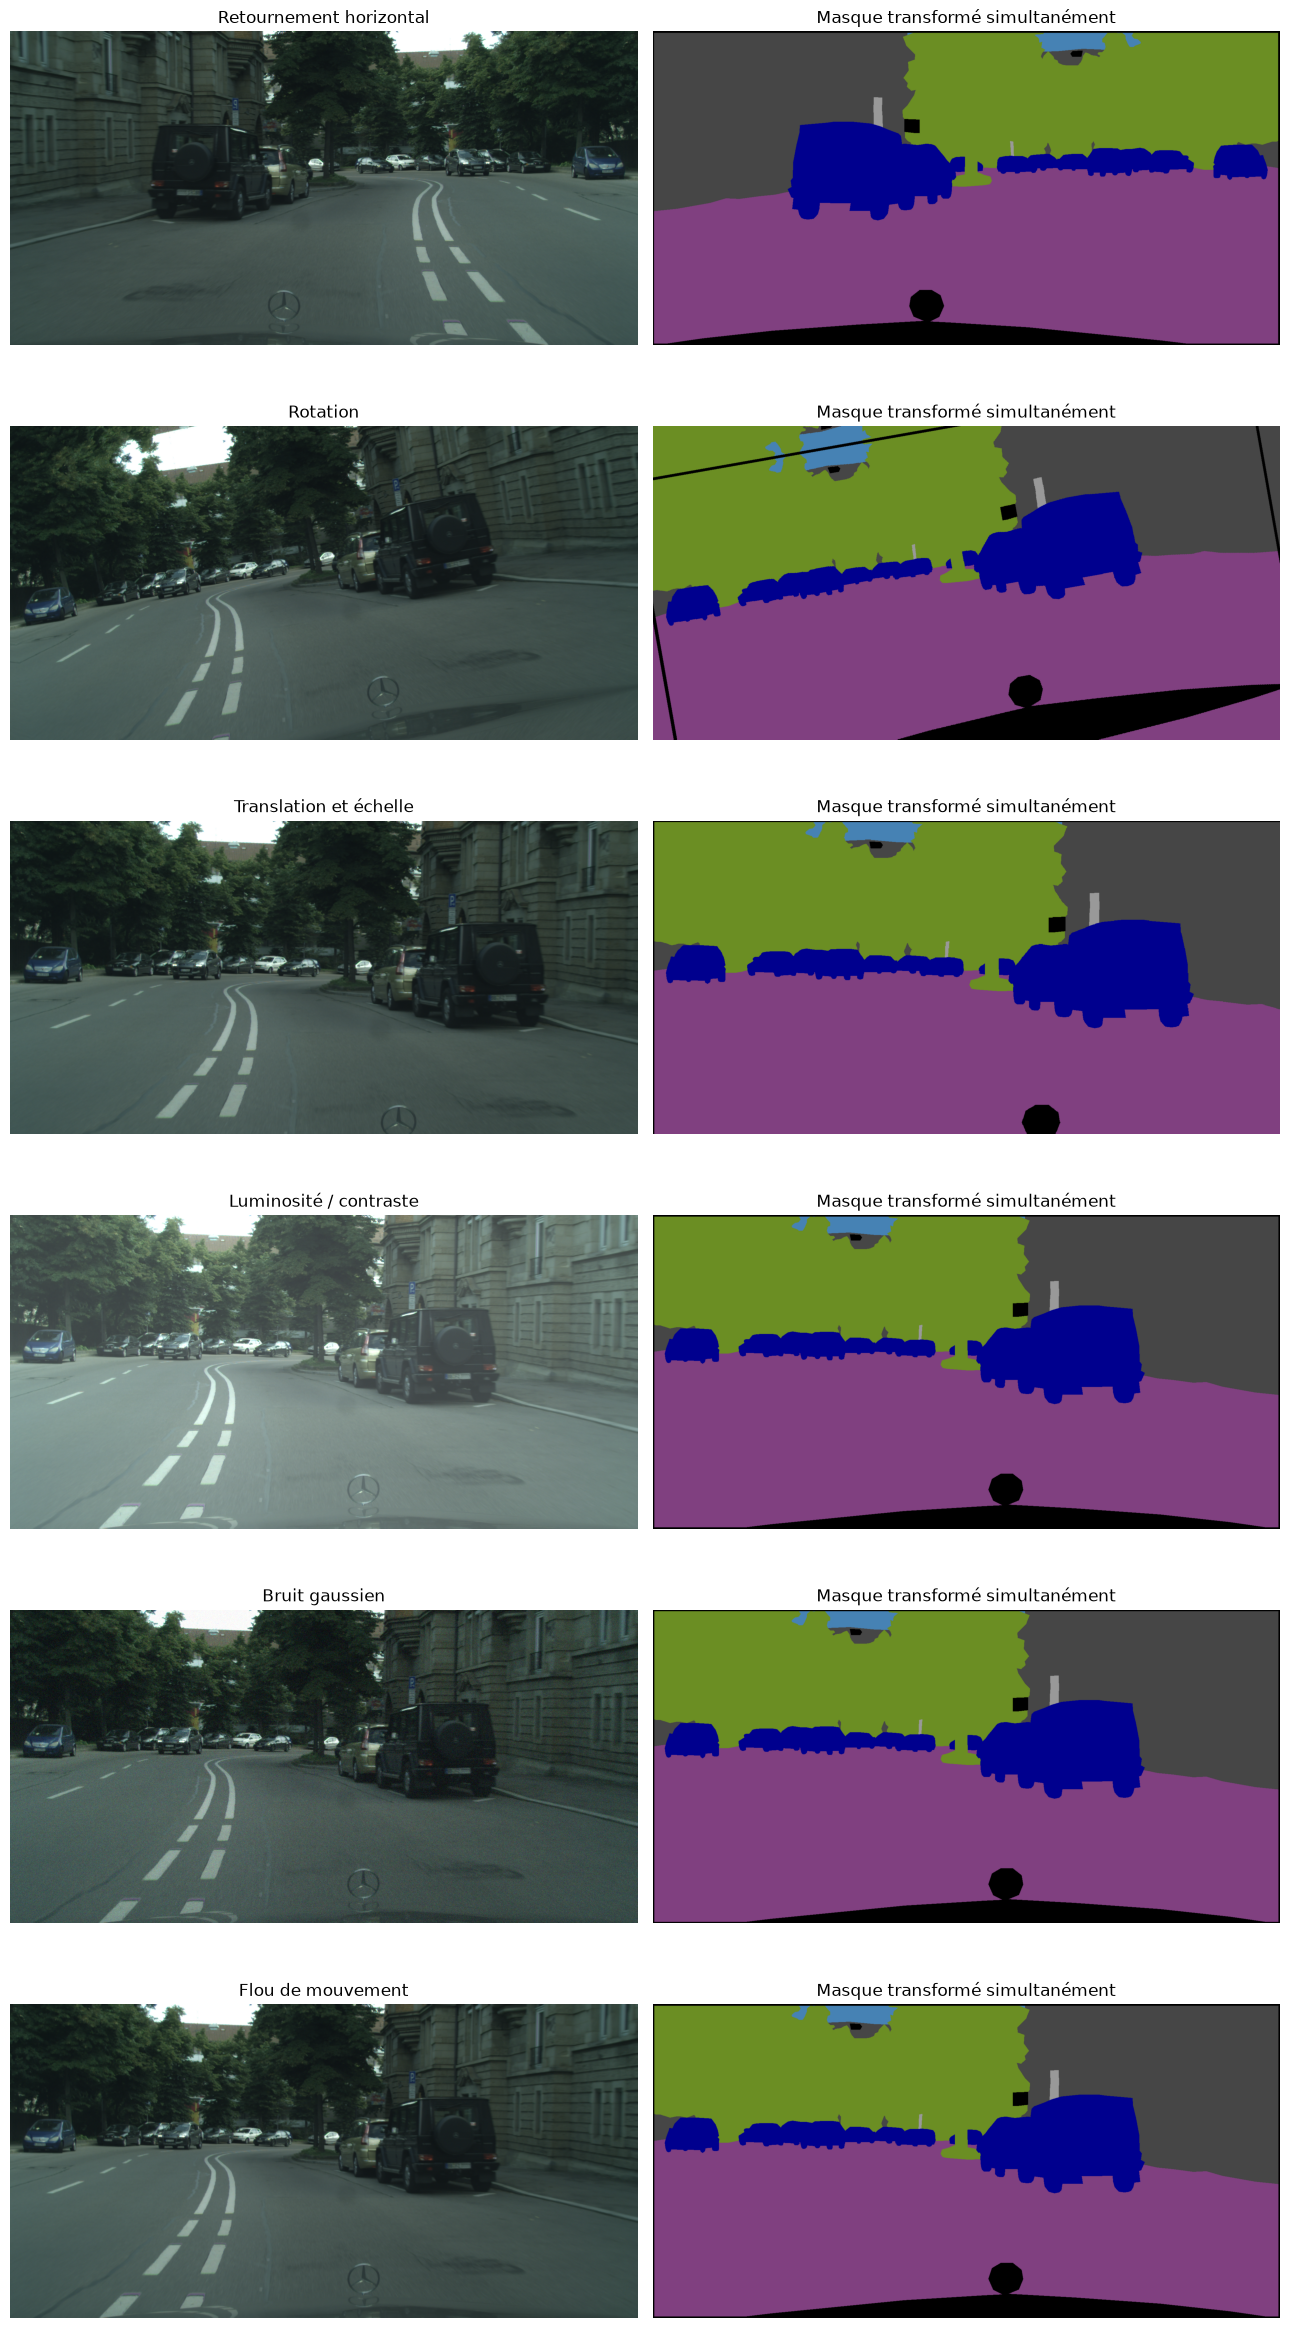

In [7]:
augmentations_exemples = {
    "Retournement horizontal": A.HorizontalFlip(p=1),
    "Rotation": A.Rotate(limit=(10, 10), border_mode=cv2.BORDER_REFLECT_101, p=1),
    "Translation et échelle": A.ShiftScaleRotate(shift_limit=(0.05, 0.05), scale_limit=(0.10, 0.10), rotate_limit=0, border_mode=cv2.BORDER_REFLECT_101, p=1),
    "Luminosité / contraste": A.RandomBrightnessContrast(brightness_limit=(0.18, 0.18), contrast_limit=(0.15, 0.15), p=1),
    "Bruit gaussien": A.GaussNoise(std_range=(0.05, 0.05), p=1),
    "Flou de mouvement": A.MotionBlur(blur_limit=(5, 5), p=1),
}

fig, axes = plt.subplots(len(augmentations_exemples), 2, figsize=(13, 4 * len(augmentations_exemples)))
for indice, (nom, augmentation) in enumerate(augmentations_exemples.items()):
    resultat = augmentation(image=image, mask=masque)
    axes[indice, 0].imshow(resultat["image"]); axes[indice, 0].set_title(nom); axes[indice, 0].axis("off")
    axes[indice, 1].imshow(COULEURS_CATEGORIES[resultat["mask"]]); axes[indice, 1].set_title("Masque transformé simultanément"); axes[indice, 1].axis("off")
plt.tight_layout()

### 8. Prétraitement unique et cache des données pour l’entraînement

In [8]:
DOSSIER_PRETRAITE = RACINE_PROJET / "data" / "pretraitees"
CHEMIN_INDEX_PRETRAITE = DOSSIER_PRETRAITE / "index_pretraite.csv"

if CHEMIN_INDEX_PRETRAITE.exists():
    tableau_donnees_pretraitees = pd.read_csv(CHEMIN_INDEX_PRETRAITE)
    print("Données prétraitées chargées depuis le cache.")
else:
    print("Prétraitement unique des images et masques...")
    tableau_donnees_pretraitees = pretraiter_donnees(
        tableau=tableau_donnees,
        dossier_sortie=DOSSIER_PRETRAITE,
        largeur=LARGEUR_IMAGE,
        hauteur=HAUTEUR_IMAGE,
    )
    DOSSIER_PRETRAITE.mkdir(parents=True, exist_ok=True)
    tableau_donnees_pretraitees.to_csv(CHEMIN_INDEX_PRETRAITE, index=False)
    print("Prétraitement terminé et index sauvegardé.")

# Même séparation déterministe que précédemment, mais sur les fichiers prétraités.
tableau_entrainement, tableau_validation = separer_donnees(
    tableau_donnees_pretraitees,
    PROPORTION_VALIDATION,
    GRAINE,
)

print("Données prétraitées :", len(tableau_donnees_pretraitees))
print("Entraînement :", len(tableau_entrainement))
print("Validation :", len(tableau_validation))
display(tableau_donnees_pretraitees.head())

Prétraitement unique des images et masques...
Prétraitement terminé et index sauvegardé.
Données prétraitées : 2974
Entraînement : 2379
Validation : 595


,ville,chemin_image,chemin_masque
0,aachen,/home/david/future_vision_transport_xpu/data/p...,/home/david/future_vision_transport_xpu/data/p...
1,aachen,/home/david/future_vision_transport_xpu/data/p...,/home/david/future_vision_transport_xpu/data/p...
2,aachen,/home/david/future_vision_transport_xpu/data/p...,/home/david/future_vision_transport_xpu/data/p...
3,aachen,/home/david/future_vision_transport_xpu/data/p...,/home/david/future_vision_transport_xpu/data/p...
4,aachen,/home/david/future_vision_transport_xpu/data/p...,/home/david/future_vision_transport_xpu/data/p...


## Partie 2 — Entraînement séparé et suivi MLflow

Chaque section peut être exécutée séparément. Les quatre modèles utilisent exactement les mêmes tableaux d’entraînement et de validation. Les poids et historiques sont sauvegardés dans `.artifacts_segmentation`.

In [4]:
POIDS_CLASSES = torch.tensor(
    [
        0.0,    # vide - ignorée
        0.264,  # plat
        0.467,  # construction
        5.802,  # objet
        0.678,  # nature
        2.880,  # ciel
        8.546,  # humain
        1.392,  # vehicule
    ],
    dtype=torch.float32,
)

print("Poids des classes :", POIDS_CLASSES)

Poids des classes : tensor([0.0000, 0.2640, 0.4670, 5.8020, 0.6780, 2.8800, 8.5460, 1.3920])


### 1. Entraînement — U-Net baseline

In [6]:
configuration = CONFIGURATIONS_MODELES["unet_baseline"]
modele_unet_baseline = construire_modele("unet_baseline", NOMBRE_CLASSES, configuration["poids_preentraines"])
#chargeur_entrainement, chargeur_validation = CHARGEURS["unet_baseline"]
chargeur_entrainement, chargeur_validation = creer_chargeurs(
    tableau_entrainement=tableau_entrainement,
    tableau_validation=tableau_validation,
    largeur=LARGEUR_IMAGE,
    hauteur=HAUTEUR_IMAGE,
    taille_lot=configuration["taille_lot"],
    nombre_travailleurs=NOMBRE_TRAVAILLEURS,
    donnees_pretraitees=True,
)

In [7]:
images_test, masques_test = next(iter(chargeur_entrainement))

print("Images :", images_test.shape)
print("Masques :", masques_test.shape)

Images : torch.Size([4, 3, 128, 256])
Masques : torch.Size([4, 128, 256])


In [17]:
configuration = CONFIGURATIONS_MODELES["unet_baseline"]
modele_unet_baseline = construire_modele("unet_baseline", NOMBRE_CLASSES, configuration["poids_preentraines"])
#chargeur_entrainement, chargeur_validation = CHARGEURS["unet_baseline"]
chargeur_entrainement, chargeur_validation = creer_chargeurs(
    tableau_entrainement=tableau_entrainement,
    tableau_validation=tableau_validation,
    largeur=LARGEUR_IMAGE,
    hauteur=HAUTEUR_IMAGE,
    taille_lot=configuration["taille_lot"],
    nombre_travailleurs=NOMBRE_TRAVAILLEURS,
    donnees_pretraitees=True,
)

parametres_unet_baseline = {
    "largeur_image": LARGEUR_IMAGE,
    "hauteur_image": HAUTEUR_IMAGE,
    "nombre_classes": NOMBRE_CLASSES,
    "images_entrainement": len(tableau_entrainement),
    "images_validation": len(tableau_validation),
    "taille_lot": configuration["taille_lot"],
    "nombre_epoques_maximum": configuration["nombre_epoques"],
    "taux_apprentissage": configuration["taux_apprentissage"],
    "augmentation": True,
    "graine": GRAINE,
}

resultat_unet_baseline = entrainer_modele_mlflow(
    modele=modele_unet_baseline, nom_modele="unet_baseline", architecture="U-Net baseline",
    chargeur_entrainement=chargeur_entrainement,
    chargeur_validation=chargeur_validation,
    peripherique=PERIPHERIQUE, nombre_classes=NOMBRE_CLASSES,
    nombre_epoques=configuration["nombre_epoques"],
    taux_apprentissage=configuration["taux_apprentissage"],
    patience=configuration["patience"], dossier_artifacts=DOSSIER_ARTIFACTS,
    parametres=parametres_unet_baseline,
)
display(pd.DataFrame([resultat_unet_baseline]))

unet_baseline | époque 01 | perte val=0.4244 | mIoU=0.5296 | Dice=0.6007
unet_baseline | époque 02 | perte val=0.4548 | mIoU=0.4966 | Dice=0.5755
unet_baseline | époque 03 | perte val=0.4335 | mIoU=0.5241 | Dice=0.5976
unet_baseline | époque 04 | perte val=0.3376 | mIoU=0.5509 | Dice=0.6219
unet_baseline | époque 05 | perte val=0.3706 | mIoU=0.5628 | Dice=0.6501
unet_baseline | époque 06 | perte val=0.3541 | mIoU=0.5658 | Dice=0.6451
unet_baseline | époque 07 | perte val=0.2863 | mIoU=0.6046 | Dice=0.6808
unet_baseline | époque 08 | perte val=0.2925 | mIoU=0.5960 | Dice=0.6820
unet_baseline | époque 09 | perte val=0.2736 | mIoU=0.6150 | Dice=0.6925
unet_baseline | époque 10 | perte val=0.2657 | mIoU=0.6293 | Dice=0.7094
unet_baseline | époque 11 | perte val=0.2681 | mIoU=0.6324 | Dice=0.7159
unet_baseline | époque 12 | perte val=0.2645 | mIoU=0.6278 | Dice=0.7067
unet_baseline | époque 13 | perte val=0.2650 | mIoU=0.6375 | Dice=0.7215
unet_baseline | époque 14 | perte val=0.2727 | mIoU

,nom_modele,architecture,miou_validation,dice_validation,perte_validation,precision_pixel_validation,temps_entrainement_secondes,meilleure_epoque,run_id,chemin_poids,peripherique
0,unet_baseline,U-Net baseline,0.661652,0.748124,0.241952,0.918038,2771.597646,18,b373a04419044138a38181aaaca773e9,/home/david/future_vision_transport_xpu/.artif...,xpu


In [7]:
parametres_unet_baseline = {
    "largeur_image": LARGEUR_IMAGE,
    "hauteur_image": HAUTEUR_IMAGE,
    "nombre_classes": NOMBRE_CLASSES,
    "images_entrainement": len(tableau_entrainement),
    "images_validation": len(tableau_validation),
    "taille_lot": configuration["taille_lot"],
    "nombre_epoques_maximum": configuration["nombre_epoques"],
    "taux_apprentissage": configuration["taux_apprentissage"],
    "augmentation": True,
    "graine": GRAINE,
}

resultat_unet_baseline_weighted = entrainer_modele_mlflow(
    modele=modele_unet_baseline,
    nom_modele="unet_baseline_weighted",
    architecture="U-Net baseline",
    chargeur_entrainement=chargeur_entrainement,
    chargeur_validation=chargeur_validation,
    peripherique=PERIPHERIQUE,
    nombre_classes=NOMBRE_CLASSES,
    nombre_epoques=configuration["nombre_epoques"],
    taux_apprentissage=configuration["taux_apprentissage"],
    patience=configuration["patience"],
    dossier_artifacts=DOSSIER_ARTIFACTS,
    parametres={
        **parametres_unet_baseline,
        "ponderation_classes": True,
    },
    poids_classes=POIDS_CLASSES,
)


unet_baseline_weighted — Époque 1/30


unet_baseline_weighted | époque 01 | perte val=0.7803 | mIoU=0.4965 | Dice=0.6076
✓ Nouvelle meilleure mIoU : 0.4965

unet_baseline_weighted — Époque 2/30


unet_baseline_weighted | époque 02 | perte val=0.7468 | mIoU=0.5259 | Dice=0.6358
✓ Nouvelle meilleure mIoU : 0.5259

unet_baseline_weighted — Époque 3/30


unet_baseline_weighted | époque 03 | perte val=0.5965 | mIoU=0.5410 | Dice=0.6540
✓ Nouvelle meilleure mIoU : 0.5410

unet_baseline_weighted — Époque 4/30


unet_baseline_weighted | époque 04 | perte val=0.5744 | mIoU=0.5329 | Dice=0.6409
Pas d'amélioration de la mIoU (1/4)

unet_baseline_weighted — Époque 5/30


...

unet_baseline_weighted | époque 21 | perte val=0.4175 | mIoU=0.6611 | Dice=0.7599
✓ Nouvelle meilleure mIoU : 0.6611

unet_baseline_weighted — Époque 22/30


unet_baseline_weighted | époque 22 | perte val=0.4074 | mIoU=0.6219 | Dice=0.7231
Pas d'amélioration de la mIoU (1/4)

unet_baseline_weighted — Époque 23/30


unet_baseline_weighted | époque 23 | perte val=0.3859 | mIoU=0.6179 | Dice=0.7238
Pas d'amélioration de la mIoU (2/4)

unet_baseline_weighted — Époque 24/30


unet_baseline_weighted | époque 24 | perte val=0.3909 | mIoU=0.6435 | Dice=0.7467
Pas d'amélioration de la mIoU (3/4)

unet_baseline_weighted — Époque 25/30


unet_baseline_weighted | époque 25 | perte val=0.3645 | mIoU=0.6494 | Dice=0.7500
Pas d'amélioration de la mIoU (4/4)

Early stopping : aucune amélioration pendant 4 époques.


### 2.1 Entraînement — U-Net + MobileNetV2

In [18]:
configuration = CONFIGURATIONS_MODELES["unet_mobilenetv2"]
modele_unet_mobilenetv2 = construire_modele("unet_mobilenetv2", NOMBRE_CLASSES, configuration["poids_preentraines"])
chargeur_entrainement, chargeur_validation = creer_chargeurs(
    tableau_entrainement=tableau_entrainement,
    tableau_validation=tableau_validation,
    largeur=LARGEUR_IMAGE,
    hauteur=HAUTEUR_IMAGE,
    taille_lot=configuration["taille_lot"],
    nombre_travailleurs=NOMBRE_TRAVAILLEURS,
    donnees_pretraitees=True,
)

parametres_unet_mobilenetv2 = {
    "largeur_image": LARGEUR_IMAGE,
    "hauteur_image": HAUTEUR_IMAGE,
    "nombre_classes": NOMBRE_CLASSES,
    "images_entrainement": len(tableau_entrainement),
    "images_validation": len(tableau_validation),
    "taille_lot": configuration["taille_lot"],
    "nombre_epoques_maximum": configuration["nombre_epoques"],
    "taux_apprentissage": configuration["taux_apprentissage"],
    "augmentation": True,
    "graine": GRAINE,
}

resultat_unet_mobilenetv2 = entrainer_modele_mlflow(
    modele=modele_unet_mobilenetv2, nom_modele="unet_mobilenetv2", architecture="U-Net + MobileNetV2",
    chargeur_entrainement=chargeur_entrainement,
    chargeur_validation=chargeur_validation,
    peripherique=PERIPHERIQUE, nombre_classes=NOMBRE_CLASSES,
    nombre_epoques=configuration["nombre_epoques"],
    taux_apprentissage=configuration["taux_apprentissage"],
    patience=configuration["patience"], dossier_artifacts=DOSSIER_ARTIFACTS,
    parametres=parametres_unet_mobilenetv2,
)
display(pd.DataFrame([resultat_unet_mobilenetv2]))

unet_mobilenetv2 | époque 01 | perte val=0.3844 | mIoU=0.5554 | Dice=0.6205
unet_mobilenetv2 | époque 02 | perte val=0.3054 | mIoU=0.5802 | Dice=0.6433
unet_mobilenetv2 | époque 03 | perte val=0.2800 | mIoU=0.6084 | Dice=0.6775
unet_mobilenetv2 | époque 04 | perte val=0.2682 | mIoU=0.6258 | Dice=0.6986
unet_mobilenetv2 | époque 05 | perte val=0.2566 | mIoU=0.6346 | Dice=0.7094
unet_mobilenetv2 | époque 06 | perte val=0.2453 | mIoU=0.6425 | Dice=0.7194
unet_mobilenetv2 | époque 07 | perte val=0.2390 | mIoU=0.6528 | Dice=0.7311
unet_mobilenetv2 | époque 08 | perte val=0.2348 | mIoU=0.6588 | Dice=0.7403
unet_mobilenetv2 | époque 09 | perte val=0.2255 | mIoU=0.6685 | Dice=0.7505
unet_mobilenetv2 | époque 10 | perte val=0.2225 | mIoU=0.6765 | Dice=0.7615
unet_mobilenetv2 | époque 11 | perte val=0.2183 | mIoU=0.6774 | Dice=0.7603
unet_mobilenetv2 | époque 12 | perte val=0.2211 | mIoU=0.6697 | Dice=0.7512
unet_mobilenetv2 | époque 13 | perte val=0.2149 | mIoU=0.6786 | Dice=0.7612
unet_mobilen

,nom_modele,architecture,miou_validation,dice_validation,perte_validation,precision_pixel_validation,temps_entrainement_secondes,meilleure_epoque,run_id,chemin_poids,peripherique
0,unet_mobilenetv2,U-Net + MobileNetV2,0.702651,0.786284,0.194685,0.931927,7088.748385,28,325e42b82ae64fa09e57dc134ad4e901,/home/david/future_vision_transport_xpu/.artif...,xpu


### 2.2 Entraînement — U-Net + MobileNetV2 avec poids

In [8]:
configuration = CONFIGURATIONS_MODELES["unet_mobilenetv2"]
modele_unet_mobilenetv2 = construire_modele("unet_mobilenetv2", NOMBRE_CLASSES, configuration["poids_preentraines"])
chargeur_entrainement, chargeur_validation = creer_chargeurs(
    tableau_entrainement=tableau_entrainement,
    tableau_validation=tableau_validation,
    largeur=LARGEUR_IMAGE,
    hauteur=HAUTEUR_IMAGE,
    taille_lot=configuration["taille_lot"],
    nombre_travailleurs=NOMBRE_TRAVAILLEURS,
    donnees_pretraitees=True,
)

parametres_unet_mobilenetv2 = {
    "largeur_image": LARGEUR_IMAGE,
    "hauteur_image": HAUTEUR_IMAGE,
    "nombre_classes": NOMBRE_CLASSES,
    "images_entrainement": len(tableau_entrainement),
    "images_validation": len(tableau_validation),
    "taille_lot": configuration["taille_lot"],
    "nombre_epoques_maximum": configuration["nombre_epoques"],
    "taux_apprentissage": configuration["taux_apprentissage"],
    "augmentation": True,
    "graine": GRAINE,
}

resultat_unet_mobilenetv2 = entrainer_modele_mlflow(
    modele=modele_unet_mobilenetv2, nom_modele="unet_mobilenetv2_weighted", architecture="U-Net + MobileNetV2",
    chargeur_entrainement=chargeur_entrainement,
    chargeur_validation=chargeur_validation,
    peripherique=PERIPHERIQUE, nombre_classes=NOMBRE_CLASSES,
    nombre_epoques=configuration["nombre_epoques"],
    taux_apprentissage=configuration["taux_apprentissage"],
    patience=configuration["patience"], dossier_artifacts=DOSSIER_ARTIFACTS,
    parametres={
        **parametres_unet_mobilenetv2,
        "ponderation_classes": True,
    },
    poids_classes=POIDS_CLASSES,
)
display(pd.DataFrame([resultat_unet_mobilenetv2]))


unet_mobilenetv2_weighted — Époque 1/30


unet_mobilenetv2_weighted | époque 01 | perte val=0.6306 | mIoU=0.5554 | Dice=0.6638
✓ Nouvelle meilleure mIoU : 0.5554

unet_mobilenetv2_weighted — Époque 2/30


unet_mobilenetv2_weighted | époque 02 | perte val=0.5245 | mIoU=0.5928 | Dice=0.6979
✓ Nouvelle meilleure mIoU : 0.5928

unet_mobilenetv2_weighted — Époque 3/30


unet_mobilenetv2_weighted | époque 03 | perte val=0.4915 | mIoU=0.6033 | Dice=0.7053
✓ Nouvelle meilleure mIoU : 0.6033

unet_mobilenetv2_weighted — Époque 4/30


unet_mobilenetv2_weighted | époque 04 | perte val=0.4584 | mIoU=0.6242 | Dice=0.7260
✓ Nouvelle meilleure mIoU : 0.6242

unet_mobilenetv2_weighted — Époque 5/30


...

unet_mobilenetv2_weighted | époque 18 | perte val=0.3638 | mIoU=0.6541 | Dice=0.7510
Pas d'amélioration de la mIoU (2/5)

unet_mobilenetv2_weighted — Époque 19/30


unet_mobilenetv2_weighted | époque 19 | perte val=0.3597 | mIoU=0.6614 | Dice=0.7566
Pas d'amélioration de la mIoU (3/5)

unet_mobilenetv2_weighted — Époque 20/30


unet_mobilenetv2_weighted | époque 20 | perte val=0.3580 | mIoU=0.6610 | Dice=0.7576
Pas d'amélioration de la mIoU (4/5)

unet_mobilenetv2_weighted — Époque 21/30


unet_mobilenetv2_weighted | époque 21 | perte val=0.3574 | mIoU=0.6594 | Dice=0.7558
Pas d'amélioration de la mIoU (5/5)

Early stopping : aucune amélioration pendant 5 époques.


,nom_modele,architecture,miou_validation,dice_validation,perte_validation,precision_pixel_validation,temps_entrainement_secondes,meilleure_epoque,run_id,chemin_poids,peripherique
0,unet_mobilenetv2_weighted,U-Net + MobileNetV2,0.668183,0.764784,0.37112,0.902634,5351.895878,16,aac33e6a142246af8bfd3dde9c3c89c5,/home/david/future_vision_transport_xpu/.artif...,xpu


### 3.1 Entraînement — DeepLabV3 + MobileNetV2

In [9]:
configuration = CONFIGURATIONS_MODELES["deeplabv3"]
modele_deeplabv3 = construire_modele("deeplabv3", NOMBRE_CLASSES, configuration["poids_preentraines"])
chargeur_entrainement, chargeur_validation = creer_chargeurs(
    tableau_entrainement=tableau_entrainement,
    tableau_validation=tableau_validation,
    largeur=LARGEUR_IMAGE,
    hauteur=HAUTEUR_IMAGE,
    taille_lot=configuration["taille_lot"],
    nombre_travailleurs=NOMBRE_TRAVAILLEURS,
    donnees_pretraitees=True,
)

parametres_deeplabv3 = {
    "largeur_image": LARGEUR_IMAGE,
    "hauteur_image": HAUTEUR_IMAGE,
    "nombre_classes": NOMBRE_CLASSES,
    "images_entrainement": len(tableau_entrainement),
    "images_validation": len(tableau_validation),
    "taille_lot": configuration["taille_lot"],
    "nombre_epoques_maximum": configuration["nombre_epoques"],
    "taux_apprentissage": configuration["taux_apprentissage"],
    "augmentation": True,
    "graine": GRAINE,
}

resultat_deeplabv3 = entrainer_modele_mlflow(
    modele=modele_deeplabv3, nom_modele="deeplabv3", architecture="DeepLabV3 + MobileNetV2",
    chargeur_entrainement=chargeur_entrainement,
    chargeur_validation=chargeur_validation,
    peripherique=PERIPHERIQUE, nombre_classes=NOMBRE_CLASSES,
    nombre_epoques=configuration["nombre_epoques"],
    taux_apprentissage=configuration["taux_apprentissage"],
    patience=configuration["patience"], dossier_artifacts=DOSSIER_ARTIFACTS,
    parametres=parametres_deeplabv3,
)
display(pd.DataFrame([resultat_deeplabv3]))


deeplabv3 — Époque 1/35


deeplabv3 | époque 01 | perte val=0.4256 | mIoU=0.4772 | Dice=0.5612
✓ Nouvelle meilleure mIoU : 0.4772

deeplabv3 — Époque 2/35


deeplabv3 | époque 02 | perte val=0.3323 | mIoU=0.5404 | Dice=0.6164
✓ Nouvelle meilleure mIoU : 0.5404

deeplabv3 — Époque 3/35


deeplabv3 | époque 03 | perte val=0.2986 | mIoU=0.5661 | Dice=0.6442
✓ Nouvelle meilleure mIoU : 0.5661

deeplabv3 — Époque 4/35


deeplabv3 | époque 04 | perte val=0.3177 | mIoU=0.5691 | Dice=0.6565
✓ Nouvelle meilleure mIoU : 0.5691

deeplabv3 — Époque 5/35


...

deeplabv3 | époque 32 | perte val=0.2188 | mIoU=0.6449 | Dice=0.7266
Pas d'amélioration de la mIoU (1/5)

deeplabv3 — Époque 33/35


deeplabv3 | époque 33 | perte val=0.2176 | mIoU=0.6454 | Dice=0.7254
Pas d'amélioration de la mIoU (2/5)

deeplabv3 — Époque 34/35


deeplabv3 | époque 34 | perte val=0.2183 | mIoU=0.6394 | Dice=0.7179
Pas d'amélioration de la mIoU (3/5)

deeplabv3 — Époque 35/35


deeplabv3 | époque 35 | perte val=0.2154 | mIoU=0.6435 | Dice=0.7227
Pas d'amélioration de la mIoU (4/5)


,nom_modele,architecture,miou_validation,dice_validation,perte_validation,precision_pixel_validation,temps_entrainement_secondes,meilleure_epoque,run_id,chemin_poids,peripherique
0,deeplabv3,DeepLabV3 + MobileNetV2,0.64691,0.72798,0.217965,0.922526,25986.879492,31,7c311620e6ae4ca9af1adec8edf64fbd,/home/david/future_vision_transport_xpu/.artif...,xpu


### 3.2 Entraînement — DeepLabV3 + MobileNetV2 avec poids

In [ ]:
configuration = CONFIGURATIONS_MODELES["deeplabv3"]
modele_deeplabv3 = construire_modele("deeplabv3", NOMBRE_CLASSES, configuration["poids_preentraines"])
chargeur_entrainement, chargeur_validation = creer_chargeurs(
    tableau_entrainement=tableau_entrainement,
    tableau_validation=tableau_validation,
    largeur=LARGEUR_IMAGE,
    hauteur=HAUTEUR_IMAGE,
    taille_lot=configuration["taille_lot"],
    nombre_travailleurs=NOMBRE_TRAVAILLEURS,
    donnees_pretraitees=True,
)

parametres_deeplabv3 = {
    "largeur_image": LARGEUR_IMAGE,
    "hauteur_image": HAUTEUR_IMAGE,
    "nombre_classes": NOMBRE_CLASSES,
    "images_entrainement": len(tableau_entrainement),
    "images_validation": len(tableau_validation),
    "taille_lot": configuration["taille_lot"],
    "nombre_epoques_maximum": configuration["nombre_epoques"],
    "taux_apprentissage": configuration["taux_apprentissage"],
    "augmentation": True,
    "graine": GRAINE,
}

resultat_deeplabv3 = entrainer_modele_mlflow(
    modele=modele_deeplabv3, nom_modele="deeplabv3_weighted ", architecture="DeepLabV3 + MobileNetV2",
    chargeur_entrainement=chargeur_entrainement,
    chargeur_validation=chargeur_validation,
    peripherique=PERIPHERIQUE, nombre_classes=NOMBRE_CLASSES,
    nombre_epoques=configuration["nombre_epoques"],
    taux_apprentissage=configuration["taux_apprentissage"],
    patience=configuration["patience"], dossier_artifacts=DOSSIER_ARTIFACTS,
    parametres={
        **parametres_deeplabv3,
        "ponderation_classes": True,
    },

    poids_classes=POIDS_CLASSES,
)
display(pd.DataFrame([resultat_deeplabv3]))


deeplabv3_weighted  — Époque 1/35


deeplabv3_weighted  | époque 01 | perte val=0.7345 | mIoU=0.4531 | Dice=0.5610
✓ Nouvelle meilleure mIoU : 0.4531

deeplabv3_weighted  — Époque 2/35


deeplabv3_weighted  | époque 02 | perte val=0.5960 | mIoU=0.5131 | Dice=0.6233
✓ Nouvelle meilleure mIoU : 0.5131

deeplabv3_weighted  — Époque 3/35


deeplabv3_weighted  | époque 03 | perte val=0.5391 | mIoU=0.5480 | Dice=0.6532
✓ Nouvelle meilleure mIoU : 0.5480

deeplabv3_weighted  — Époque 4/35


deeplabv3_weighted  | époque 04 | perte val=0.5111 | mIoU=0.5671 | Dice=0.6692
✓ Nouvelle meilleure mIoU : 0.5671

deeplabv3_weighted  — Époque 5/35


...

deeplabv3_weighted  | époque 06 | perte val=0.4923 | mIoU=0.5844 | Dice=0.6853
✓ Nouvelle meilleure mIoU : 0.5844

deeplabv3_weighted  — Époque 7/35


deeplabv3_weighted  | époque 07 | perte val=0.4600 | mIoU=0.5775 | Dice=0.6812
Pas d'amélioration de la mIoU (1/5)

deeplabv3_weighted  — Époque 8/35


deeplabv3_weighted  | époque 08 | perte val=0.4511 | mIoU=0.5853 | Dice=0.6857
✓ Nouvelle meilleure mIoU : 0.5853

deeplabv3_weighted  — Époque 9/35


deeplabv3_weighted  | époque 09 | perte val=0.4377 | mIoU=0.5855 | Dice=0.6863
✓ Nouvelle meilleure mIoU : 0.5855

deeplabv3_weighted  — Époque 10/35


Époque 10 - Validation:  18%|█████████████████████████████▉                                                                                                                                          | 53/298 [00:28<03:23,  1.20it/s, dice=0.7050, miou=0.6028, perte=0.4418]

### 4. Entraînement — SegFormer MiT-B0

In [10]:
configuration = CONFIGURATIONS_MODELES["segformer"]
modele_segformer = construire_modele("segformer", NOMBRE_CLASSES, configuration["poids_preentraines"])
chargeur_entrainement, chargeur_validation = creer_chargeurs(
    tableau_entrainement=tableau_entrainement,
    tableau_validation=tableau_validation,
    largeur=LARGEUR_IMAGE,
    hauteur=HAUTEUR_IMAGE,
    taille_lot=configuration["taille_lot"],
    nombre_travailleurs=NOMBRE_TRAVAILLEURS,
    donnees_pretraitees=True,
)

parametres_segformer = {
    "largeur_image": LARGEUR_IMAGE,
    "hauteur_image": HAUTEUR_IMAGE,
    "nombre_classes": NOMBRE_CLASSES,
    "images_entrainement": len(tableau_entrainement),
    "images_validation": len(tableau_validation),
    "taille_lot": configuration["taille_lot"],
    "nombre_epoques_maximum": configuration["nombre_epoques"],
    "taux_apprentissage": configuration["taux_apprentissage"],
    "augmentation": True,
    "graine": GRAINE,
}

resultat_segformer = entrainer_modele_mlflow(
    modele=modele_segformer, nom_modele="segformer", architecture="SegFormer MiT-B0",
    chargeur_entrainement=chargeur_entrainement,
    chargeur_validation=chargeur_validation,
    peripherique=PERIPHERIQUE, nombre_classes=NOMBRE_CLASSES,
    nombre_epoques=configuration["nombre_epoques"],
    taux_apprentissage=configuration["taux_apprentissage"],
    patience=configuration["patience"], dossier_artifacts=DOSSIER_ARTIFACTS,
    parametres=parametres_segformer,
)
display(pd.DataFrame([resultat_segformer]))

Some weights of SegformerForSemanticSegmentation were not initialized from the model checkpoint at nvidia/mit-b0 and are newly initialized: ['decode_head.batch_norm.bias', 'decode_head.batch_norm.num_batches_tracked', 'decode_head.batch_norm.running_mean', 'decode_head.batch_norm.running_var', 'decode_head.batch_norm.weight', 'decode_head.classifier.bias', 'decode_head.classifier.weight', 'decode_head.linear_c.0.proj.bias', 'decode_head.linear_c.0.proj.weight', 'decode_head.linear_c.1.proj.bias', 'decode_head.linear_c.1.proj.weight', 'decode_head.linear_c.2.proj.bias', 'decode_head.linear_c.2.proj.weight', 'decode_head.linear_c.3.proj.bias', 'decode_head.linear_c.3.proj.weight', 'decode_head.linear_fuse.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.



segformer — Époque 1/35


segformer | époque 01 | perte val=0.3004 | mIoU=0.5765 | Dice=0.6513
✓ Nouvelle meilleure mIoU : 0.5765

segformer — Époque 2/35


segformer | époque 02 | perte val=0.2665 | mIoU=0.5956 | Dice=0.6716
✓ Nouvelle meilleure mIoU : 0.5956

segformer — Époque 3/35


segformer | époque 03 | perte val=0.2498 | mIoU=0.6237 | Dice=0.7032
✓ Nouvelle meilleure mIoU : 0.6237

segformer — Époque 4/35


...

Époque 21 - Entraînement:  35%|████████████████████████████████████████████████████████▉                                                                                                           | 413/1189 [03:35<07:04,  1.83it/s, dice=0.7475, miou=0.6475, perte=0.1821]IOPub message rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_msg_rate_limit`.

Current values:
ServerApp.iopub_msg_rate_limit=1000.0 (msgs/sec)
ServerApp.rate_limit_window=3.0 (secs)

                                                                                                                                                                                                                                                                              

segformer | époque 22 | perte val=0.1999 | mIoU=0.6689 | Dice=0.7496
Pas d'amélioration de la mIoU (3/5)

segformer — Époque 23/35


segformer | époque 23 | perte val=0.1960 | mIoU=0.6694 | Dice=0.7487
Pas d'amélioration de la mIoU (4/5)

segformer — Époque 24/35


segformer | époque 24 | perte val=0.2014 | mIoU=0.6684 | Dice=0.7490
Pas d'amélioration de la mIoU (5/5)

Early stopping : aucune amélioration pendant 5 époques.


,nom_modele,architecture,miou_validation,dice_validation,perte_validation,precision_pixel_validation,temps_entrainement_secondes,meilleure_epoque,run_id,chemin_poids,peripherique
0,segformer,SegFormer MiT-B0,0.669932,0.750953,0.200733,0.929084,14906.835313,19,2228a39c29124783988ac1c2702f3f80,/home/david/future_vision_transport_xpu/.artif...,xpu


### 5. Tableau récapitulatif — du meilleur au moins bon

In [12]:
classement_modeles = recuperer_classement_mlflow(NOM_EXPERIENCE_MLFLOW, DOSSIER_ARTIFACTS)
display(classement_modeles)

if not classement_modeles.empty:
    meilleur = classement_modeles.iloc[0]
    plus_rapide = classement_modeles.sort_values("Temps entraînement (s)").iloc[0]
    print(f"Meilleure qualité : {meilleur['modèle']} — mIoU={meilleur['mIoU validation']:.4f}, Dice={meilleur['Dice validation']:.4f}")
    print(f"Modèle le plus rapide : {plus_rapide['modèle']} — {plus_rapide['Temps entraînement (s)']:.1f} s")
    print("Exports :", DOSSIER_ARTIFACTS / "comparaison_modeles.csv")

,Rang,modèle,architecture,mIoU validation,Dice validation,Perte validation,Précision pixel,Temps entraînement (s),Meilleure époque,Périphérique,Run MLflow
0,1,unet_mobilenetv2,U-Net + MobileNetV2,0.702651,0.786284,0.194685,0.931927,7088.748385,28.0,xpu,325e42b82ae64fa09e57dc134ad4e901
1,2,segformer,SegFormer MiT-B0,0.669932,0.750953,0.200733,0.929084,14906.835313,19.0,xpu,2228a39c29124783988ac1c2702f3f80
2,3,unet_baseline,U-Net baseline,0.661652,0.748124,0.241952,0.918038,2771.597646,18.0,xpu,b373a04419044138a38181aaaca773e9
3,4,deeplabv3,DeepLabV3 + MobileNetV2,0.646910,0.727980,0.217965,0.922526,25986.879492,31.0,xpu,7c311620e6ae4ca9af1adec8edf64fbd


Meilleure qualité : unet_mobilenetv2 — mIoU=0.7027, Dice=0.7863
Modèle le plus rapide : unet_baseline — 2771.6 s
Exports : /home/david/future_vision_transport_xpu/.artifacts_segmentation/comparaison_modeles.csv


## Conclusion

Le classement final repose prioritairement sur la **mIoU de validation**, puis sur le Dice en cas d’égalité. Le temps d’entraînement permet d’identifier le modèle le plus rapide et d’évaluer le meilleur compromis entre qualité et coût de calcul pour une intégration embarquée.